# Parcial
##Astorfisica moderna

Jesus serpa Pajaro


Una nave espacial que puede ir a velocidades relativistas (v = 0.4c) emprende un viaje desde la Tierra
en la direcci ́on del centro de la constelaci ́on del Can Mayor. Utilizando

In [ ]:
import numpy as np
import pandas as pd
from astropy import constants
import matplotlib.pyplot as plt

In [ ]:
url1 = 'https://raw.githubusercontent.com/jesuserpajaro/Udea/main/cma_data.csv'
url2 = 'https://raw.githubusercontent.com/jesuserpajaro/Udea/main/colors.csv'

In [ ]:
c = constants.c.value
deg = np.pi/180
rad = 1/deg

data = pd.read_csv(url1)
cinf = pd.read_csv(url2)

In [ ]:
data

,index,ra,dec,lam
0,1,101.288541,-16.713143,601
1,2,104.656445,-28.972089,601
2,3,107.097859,-26.393208,701
3,4,95.674948,-17.955917,601
4,5,111.023771,-29.303120,601
5,6,95.078280,-30.063377,601
6,7,105.756140,-23.833301,601
7,8,105.429799,-27.934842,774
8,9,102.460273,-32.508488,601
9,10,103.533145,-24.184223,774


## 1.Haga una grafica RA/DEC que muestre el efecto de colimacion relativıstico visto desde la nave para cada estrella en la constelacion. En la grafica se deben ver las posiciones originales de las estrellas vs. las observadas desde la nave.

## grafica inicial

sacamos el punto medio en direccion a la que va la nave

In [ ]:
rap = data['ra'].mean()
decp = data['dec'].mean()


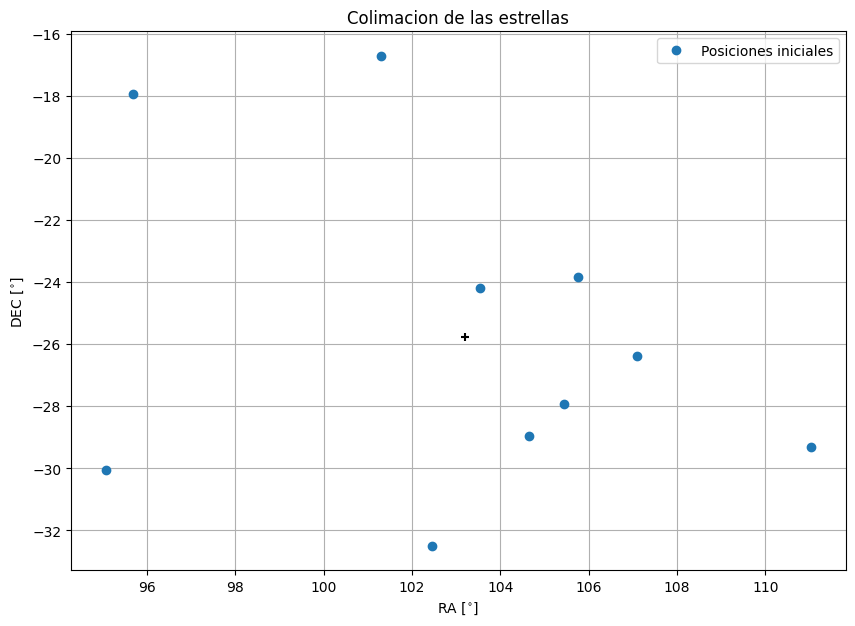

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(data['ra'], data['dec'],'o',label='Posiciones iniciales')
plt.scatter(rap,decp,c='k',marker='+')

# labels
plt.xlabel(r'RA [$^{\circ}$]')
plt.ylabel(r'DEC [$^{\circ}$]')
plt.title('Colimacion de las estrellas')

plt.grid()
plt.legend()
plt.show()

## Calcula las nuevas coordenadas de acuerdo a la colimacion relativista

Primeramente de acuerdo a la siguiente equacion

$$ \tan \theta=\frac{\sin \theta^{\prime}}{\gamma\left(\cos \theta^{\prime}+v / c\right)}$$

creamos una rutina para poder calcular la colimasion del angulo

In [ ]:
def colimacion(θ,v):

  γ = 1/np.sqrt(1 - ((v * c)**2/c**2) )
  p = np.sin(θ*deg)
  q = γ * (np.cos(θ*deg) + ((v*c)/c))

  newθ = np.arctan(p/q)
  if p*q<0 and q<0:
    newθ = newθ + np.pi
  elif p*q<0 and q>0:
    newθ = newθ + 2*np.pi
  elif p+q<0:
    newθ = newθ + np.pi
  return newθ*rad

Para resolver la correcion de coordenadas por colimacion primeramente necesitamos calcular la separacion entre estas coordenadas, en este caso el centro del sistema y cada una de los puntos, para esto usando astronomia de posicion, podemos calcular primeramente la separacion de los puntos usando trigonometria esferica.

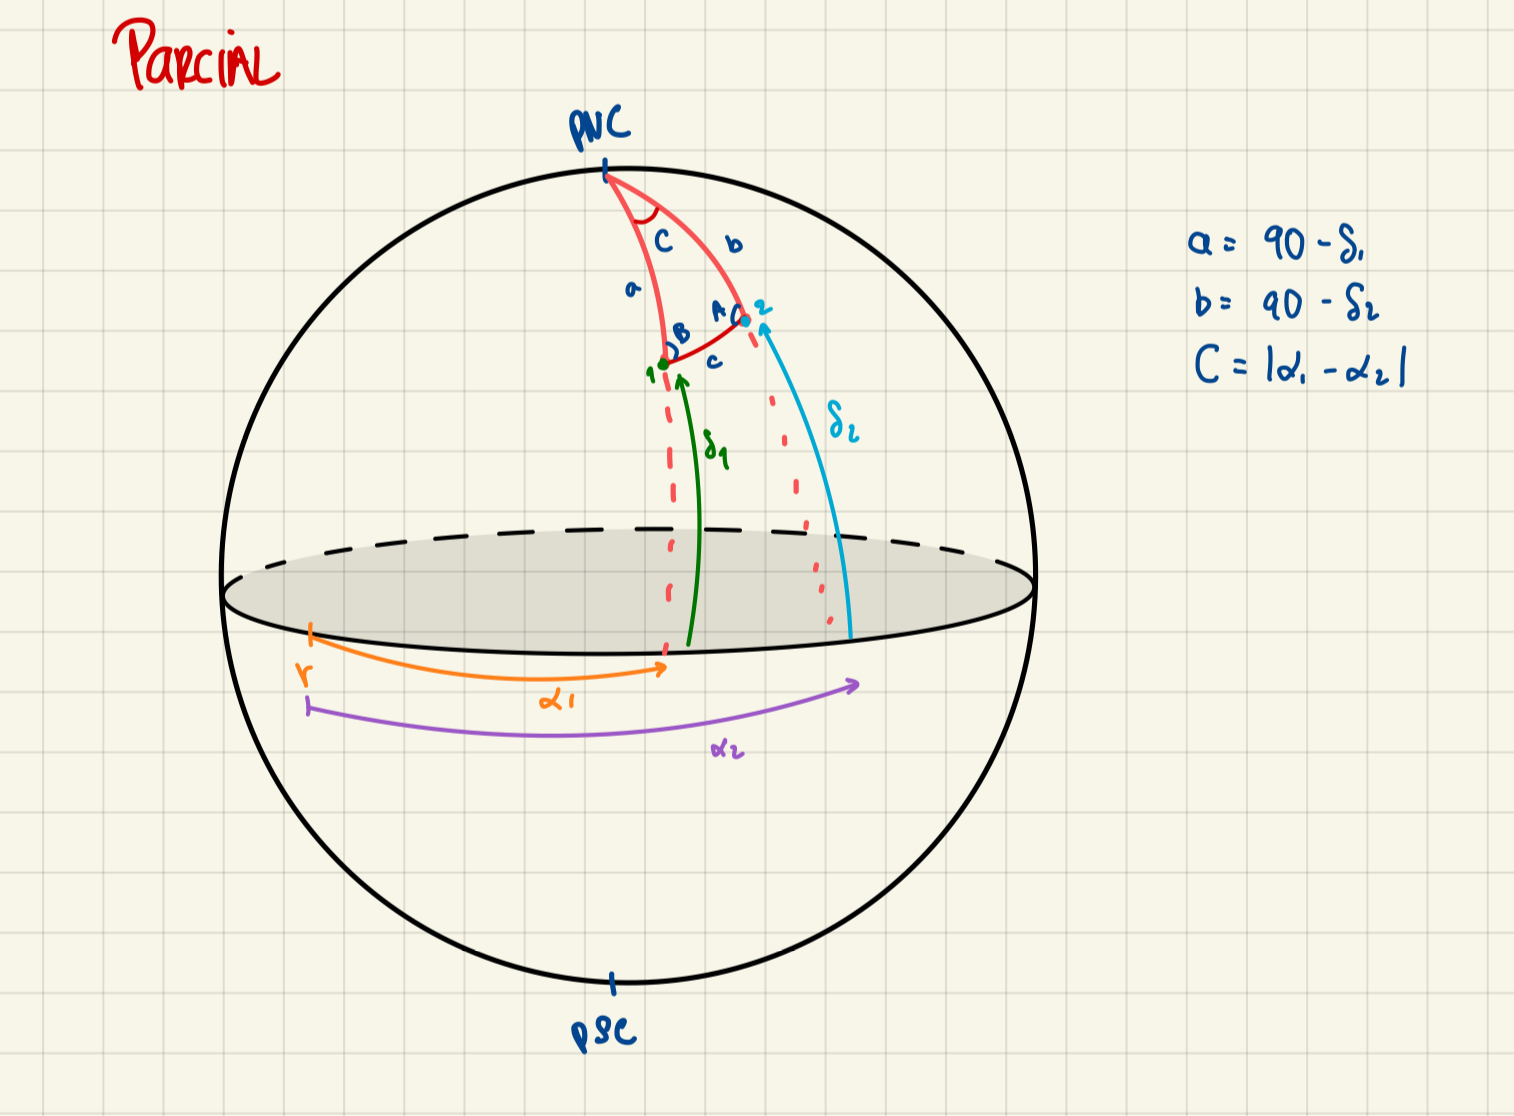

In [ ]:
def newcoordenade(α, δ, v,decp,rap):
    a = 90 - decp
    b = 90 - δ
    C = abs(α - rap)

    c = np.arccos(np.cos(a * deg) * np.cos(b * deg) + np.sin(b * deg) * np.sin(a * deg) * np.cos(C * deg))
    A = np.arcsin((np.sin(C* deg) * np.sin(a* deg)) / np.sin(c))

    #colimamos la distancia
    cnew = colimacion(c*rad, v)
    Cnew = np.arcsin((np.sin(cnew*deg) * np.sin(A)) / np.sin(a*deg))

    #Nueva ascension recta
    αnew = abs(rap + (Cnew * rad)) if rap < α else abs(rap - (Cnew * rad))

    if δ > decp:
      Anew = 180 - (A*rad)
      bnew = np.abs( np.arcsin((np.cos(cnew*deg) - (np.cos(a*deg)**2 / np.cos(cnew*deg))) / (np.sin(a*deg) * np.cos(Cnew) - np.cos(a*deg) * np.tan(cnew*deg) * np.cos(Anew*deg))) ) *rad
      δnew = -(bnew - 90)
    else:
        p = (np.cos((Cnew + A)/2)) / np.cos((Cnew - A)/2)
        q = np.tan(((a*deg) + (cnew*deg))/2)
        bnew  = abs(2*np.arctan(p*q))
        δnew =(bnew*rad) - 90


    return αnew, -δnew,cnew

In [ ]:
αnew = np.zeros(10)
δnew = np.zeros_like(αnew)
cnew = np.zeros_like(αnew)
for i in range(len(αnew)):
    αnew[i] = newcoordenade(data['ra'][i], data['dec'][i], 0.4,decp,rap)[0]
    δnew[i] = newcoordenade(data['ra'][i], data['dec'][i], 0.4,decp,rap)[1]
    cnew[i] = newcoordenade(data['ra'][i], data['dec'][i], 0.4,decp,rap)[2]


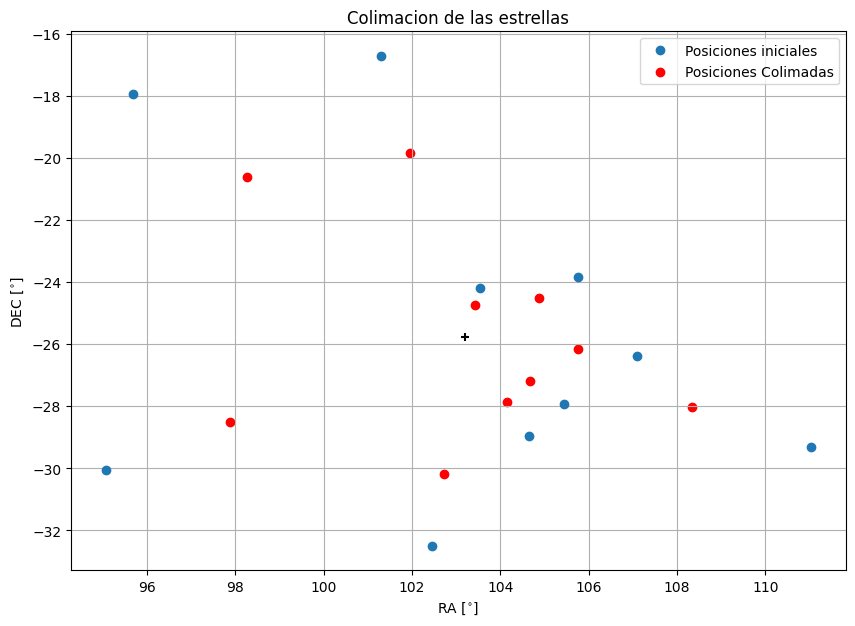

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(data['ra'], data['dec'],'o',label='Posiciones iniciales')
plt.scatter(αnew,δnew,c='r',label='Posiciones Colimadas')
plt.scatter(rap,decp,c='k',marker='+')

# labels
plt.xlabel(r'RA [$^{\circ}$]')
plt.ylabel(r'DEC [$^{\circ}$]')
plt.title('Colimacion de las estrellas')
plt.legend()
plt.grid()
plt.show()

## 2. Haga una gr ́afica RA/DEC que muestre el corrimiento Doppler relativ ́ıstico de la longitud de onda (color) visto desde la nave para cada estrella en la constelacion. Recuerde tener en cuenta el  angulo entre la direccion del desplazamiento de la nave y la ubicacion de cada estrella. Para ilustrar el color, guıese con el notebook CMA.ipynb adjunto, para el que se necesita el archivo colors.csv.

Defimos el efecto doppler relativista como
$$
\lambda_{obs}=\lambda_{em}\left ( \frac{1-\frac{v}{c}cos(θ)}{\sqrt{1+\left ( \frac{v}{c} \right )^{2}}} \right )
$$

In [ ]:
lam = data['lam']

In [ ]:
def ef_doppler(λ_em,θ,v):
  γ = 1/np.sqrt(1 - ((v * c)**2/c**2) )
  λ_obs = λ_em * γ * ( 1 - (v * np.cos(θ*deg)))
  return λ_obs

Aplicamos el efecto doppler para la longitudes de onda


In [ ]:
λnew = np.zeros_like(lam)

for i in range(len(λnew )):
  λnew[i] =  ef_doppler(lam[i],cnew[i] ,0.4)

In [ ]:
lamround=5*round(data.lam/5)
colors=[cinf.hex[cinf.lamc==i].iloc[0] for i in lamround]

In [ ]:
data['λnew'] =λnew
lamnew=5*round(data.λnew/5)
colorsnew=[cinf.hex[cinf.lamc==i].iloc[0] for i in lamnew]

In [ ]:
dat = pd.DataFrame({'λnew': λnew})


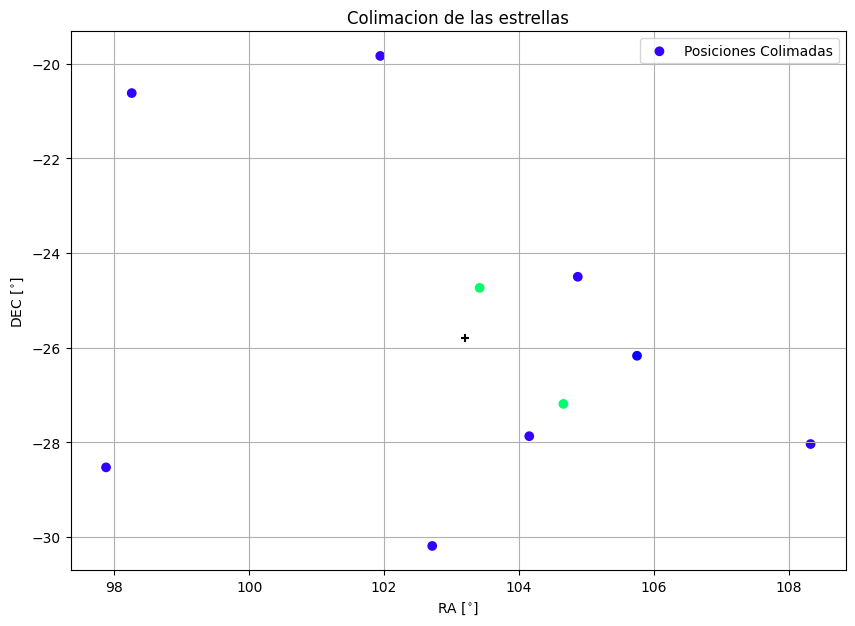

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(αnew,δnew,c=colorsnew,label='Posiciones Colimadas')
plt.scatter(rap,decp,c='k',marker='+')

# labels
plt.xlabel(r'RA [$^{\circ}$]')
plt.ylabel(r'DEC [$^{\circ}$]')
plt.title('Colimacion de las estrellas')
plt.legend()
plt.grid()
plt.show()

## 3. Una las dos graficas para evidenciar los efectos de colimacion y Doppler relativista al mismo tiempo.

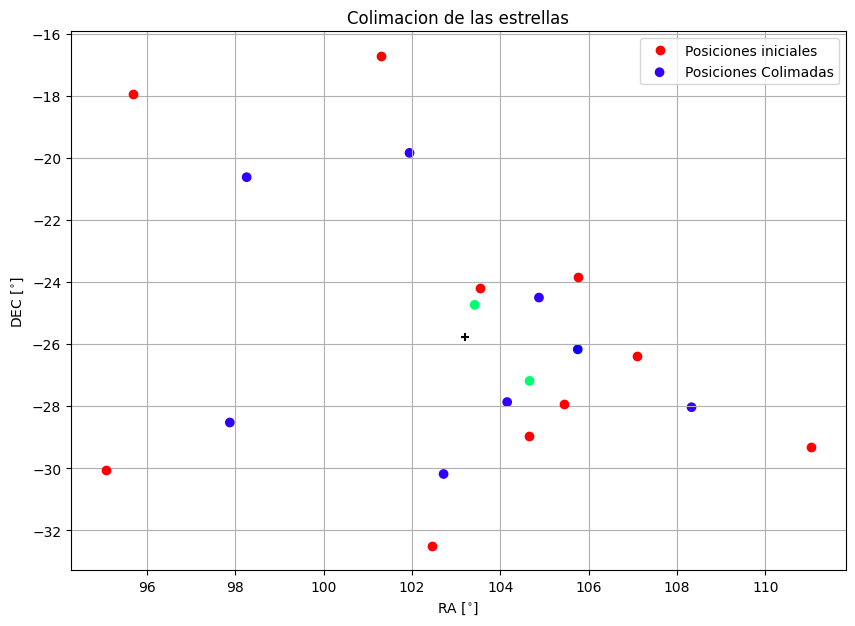

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(data['ra'], data['dec'],'ro',label='Posiciones iniciales')
plt.scatter(αnew,δnew,c=colorsnew,label='Posiciones Colimadas')
plt.scatter(rap,decp,c='k',marker='+')

# labels
plt.xlabel(r'RA [$^{\circ}$]')
plt.ylabel(r'DEC [$^{\circ}$]')
plt.title('Colimacion de las estrellas')
plt.legend()
plt.grid()
plt.show()

##  4. Sobre la misma grafica del punto 3. grafique la colimacion/efecto Doppler para v = 0.1c, 0.2c, 0.3c.

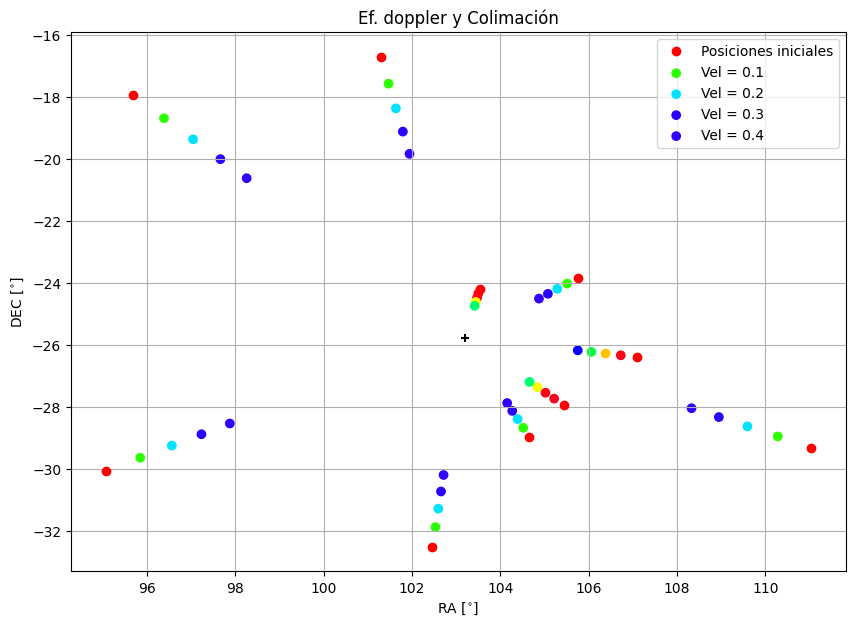

In [ ]:
#formamos las listas
vs = np.array([0.1, 0.2, 0.3, 0.4])
rs = np.zeros((len(vs), 3, 10))

farbes = []

#calculamos las coordenadas como en el ejercicio anterior
for i in range(len(vs)):
    αnew = np.zeros(10)
    δnew = np.zeros_like(αnew)
    cnew = np.zeros_like(αnew)

    for j in range(len(αnew)):
        αnew[j] = newcoordenade(data['ra'][j], data['dec'][j], vs[i], decp, rap)[0]
        δnew[j] = newcoordenade(data['ra'][j], data['dec'][j], vs[i], decp, rap)[1]
        cnew[j] = newcoordenade(data['ra'][j], data['dec'][j], vs[i], decp, rap)[2]

    λnew = [ef_doppler(lam[a], cnew[a], vs[i]) for a in range(len(αnew))]

    dat = pd.DataFrame({'λnew': λnew})
    lamnew = 5 * round(dat.λnew / 5)
    farbe = [cinf.hex[cinf.lamc == i].iloc[0] for i in lamnew]
    farbes.extend(farbe)
    rs[i] = np.array([αnew, δnew, cnew])


#graficamos
fig, ax = plt.subplots(figsize=(10, 7))
plt.plot(data['ra'], data['dec'],'ro',label='Posiciones iniciales')
for i in range(len(vs)):
    ax.scatter(rs[i][0], rs[i][1], c=farbes[i * 10: (i + 1) * 10],label=f'Vel = {vs[i]}')
plt.scatter(rap,decp,c='k',marker='+')
plt.title('Ef. doppler y Colimación')
plt.xlabel(r'RA [$^{\circ}$]')
plt.ylabel(r'DEC [$^{\circ}$]')
ax.legend()
plt.grid()
plt.show()
